# Recommendation System

Data Description:

Unique ID of each anime.
Anime title.
Anime broadcast type, such as TV, OVA, etc.
anime genre.
The number of episodes of each anime.
The average rating for each anime compared to the number of users who gave ratings.


Number of community members for each anime.

Objective:

The objective of this assignment is to implement a recommendation system using cosine similarity on an anime dataset.

Dataset:

Use the Anime Dataset which contains information about various anime, including their titles, genres,No.of episodes and user ratings etc.

Tasks:

Data Preprocessing:

Load the dataset into a suitable data structure (e.g., pandas DataFrame).
Handle missing values, if any.
Explore the dataset to understand its structure and attributes.

Feature Extraction:

Decide on the features that will be used for computing similarity (e.g., genres, user ratings).
Convert categorical features into numerical representations if necessary.
Normalize numerical features if required.

Recommendation System:

Design a function to recommend anime based on cosine similarity.
Given a target anime, recommend a list of similar anime based on cosine similarity scores.
Experiment with different threshold values for similarity scores to adjust the recommendation list size.
Analyze the performance of the recommendation system and identify areas of improvement.

Interview Questions:

1. Can you explain the difference between user-based and item-based collaborative filtering?

2. What is collaborative filtering, and how does it work?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
df = pd.read_csv("/content/anime.csv")
df

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266
...,...,...,...,...,...,...,...
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,1,4.15,211
12290,5543,Under World,Hentai,OVA,1,4.28,183
12291,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4,4.88,219
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,1,4.98,175


In [ ]:
# Display number of rows and columns
print("Shape of dataset:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns)

# Display information about the dataset
print("\nDataset Information:")
df.info()

Shape of dataset: (12294, 7)

Column names:
Index(['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [ ]:
# Check missing values in each column

missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

In [ ]:
# Check missing values in each column

missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64


In [ ]:
# Fill missing numerical values with median

numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
# Fill missing categorical values with 'Unknown'

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

In [ ]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [ ]:
# Check duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
# Remove duplicate rows

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (12294, 7)


In [ ]:
print(df.columns.tolist())

['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members']


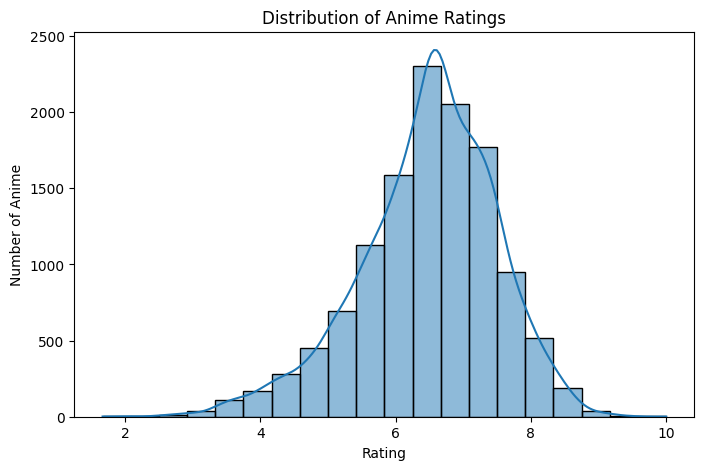

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['rating'], bins=20, kde=True)

plt.title("Distribution of Anime Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Anime")

plt.show()

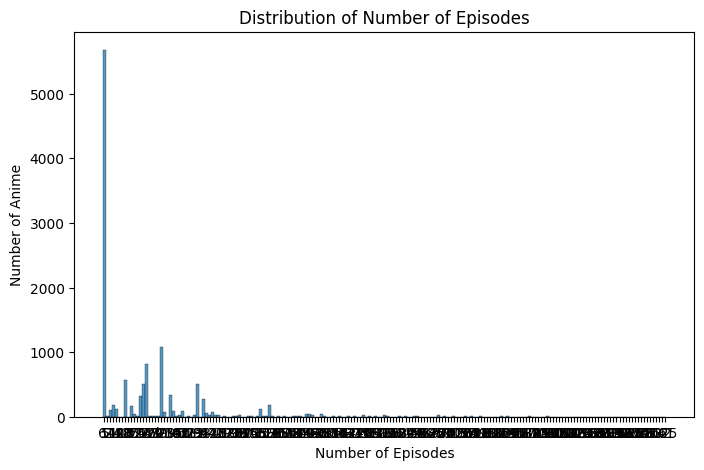

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['episodes'], bins=30)

plt.title("Distribution of Number of Episodes")
plt.xlabel("Number of Episodes")
plt.ylabel("Number of Anime")

plt.show()

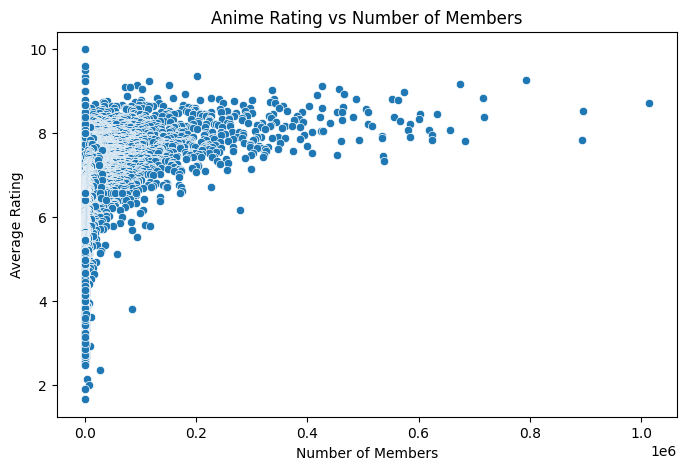

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='members',
    y='rating'
)

plt.title("Anime Rating vs Number of Members")
plt.xlabel("Number of Members")
plt.ylabel("Average Rating")

plt.show()

In [ ]:
top_anime = df.sort_values(
    by='rating',
    ascending=False
).head(10)

top_anime[['name', 'rating', 'members']]

,name,rating,members
10464,Taka no Tsume 8: Yoshida-kun no X-Files,10.00,13
10400,Spoon-hime no Swing Kitchen,9.60,47
9595,Mogura no Motoro,9.50,62
0,Kimi no Na wa.,9.37,200630
9078,Kahei no Umi,9.33,44
1,Fullmetal Alchemist: Brotherhood,9.26,793665
10786,Yakusoku: Africa Mizu to Midori,9.25,53
2,Gintama°,9.25,114262
3,Steins;Gate,9.17,673572
4,Gintama&#039;,9.16,151266


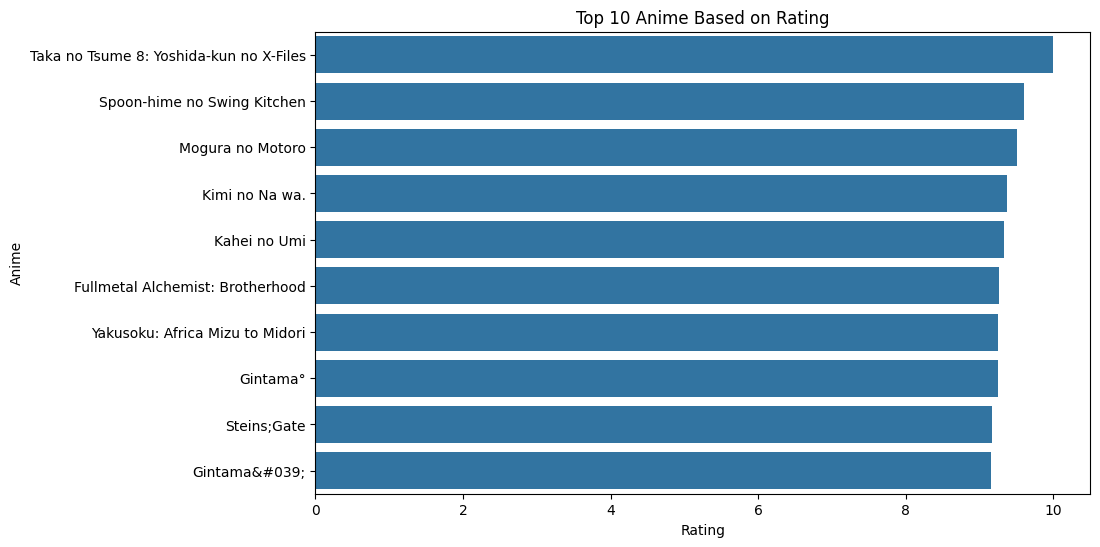

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_anime,
    x='rating',
    y='name'
)

plt.title("Top 10 Anime Based on Rating")
plt.xlabel("Rating")
plt.ylabel("Anime")

plt.show()

In [ ]:
# Replace Unknown episodes with NaN

df['episodes'] = pd.to_numeric(
    df['episodes'],
    errors='coerce'
)

# Fill missing episodes with median

df['episodes'] = df['episodes'].fillna(
    df['episodes'].median()
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert genre to string
df['genre'] = df['genre'].fillna("Unknown").astype(str)

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    stop_words='english'
)

# Transform genres
genre_matrix = tfidf.fit_transform(df['genre'])

print("Genre matrix shape:", genre_matrix.shape)

Genre matrix shape: (12294, 47)


In [ ]:
# Select numerical features

numerical_features = [
    'episodes',
    'rating',
    'members'
]

# Standardize numerical features

scaler = StandardScaler()

numeric_matrix = scaler.fit_transform(
    df[numerical_features]
)

print("Numerical matrix shape:", numeric_matrix.shape)

Numerical matrix shape: (12294, 3)


In [ ]:
from scipy.sparse import hstack

# Convert numerical matrix into sparse matrix

from scipy.sparse import csr_matrix

numeric_sparse = csr_matrix(numeric_matrix)

# Combine genre and numerical features

feature_matrix = hstack([
    genre_matrix,
    numeric_sparse
])

print("Final feature matrix shape:", feature_matrix.shape)

Final feature matrix shape: (12294, 50)


In [ ]:
# Calculate cosine similarity

cosine_sim = cosine_similarity(feature_matrix)

print("Cosine similarity matrix shape:")
print(cosine_sim.shape)

Cosine similarity matrix shape:
(12294, 12294)


In [ ]:
# Reset index

df = df.reset_index(drop=True)

# Create mapping from anime name to index

anime_indices = pd.Series(
    df.index,
    index=df['name'].str.lower()
).drop_duplicates()

In [ ]:
def recommend_anime(anime_name, num_recommendations=10):

    anime_name = anime_name.lower()

    # Check whether anime exists
    if anime_name not in anime_indices:
        return f"Anime '{anime_name}' not found in dataset."

    # Get index of selected anime
    idx = anime_indices[anime_name]

    # Get similarity scores
    similarity_scores = list(
        enumerate(cosine_sim[idx])
    )

    # Sort by similarity
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove the selected anime itself
    similarity_scores = [
        item for item in similarity_scores
        if item[0] != idx
    ]

    # Select top recommendations
    top_scores = similarity_scores[
        :num_recommendations
    ]

    # Get anime indices
    anime_ids = [item[0] for item in top_scores]

    # Get similarity values
    scores = [item[1] for item in top_scores]

    # Create result
    recommendations = df.iloc[anime_ids][
        ['name', 'genre', 'rating', 'episodes', 'members']
    ].copy()

    recommendations['similarity_score'] = scores

    return recommendations

In [ ]:
recommend_anime(
    "Naruto",
    num_recommendations=10
)

,name,genre,rating,episodes,members,similarity_score
288,Fairy Tail,"Action, Adventure, Comedy, Fantasy, Magic, Sho...",8.22,175.0,584590,0.993032
304,D.Gray-man,"Action, Adventure, Comedy, Shounen",8.20,103.0,334399,0.974623
4444,Dragon Ball GT,"Action, Adventure, Comedy, Fantasy, Magic, Sci...",6.72,64.0,226625,0.974174
6,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",9.13,148.0,425855,0.973229
346,Dragon Ball,"Adventure, Comedy, Fantasy, Martial Arts, Shou...",8.16,153.0,316102,0.972025
582,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",7.95,366.0,624055,0.967331
440,Soul Eater,"Action, Adventure, Comedy, Fantasy, Shounen, S...",8.08,51.0,580184,0.957075
200,Fullmetal Alchemist,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",8.33,51.0,600384,0.955219
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",9.26,64.0,793665,0.954936
255,Fairy Tail (2014),"Action, Adventure, Comedy, Fantasy, Magic, Sho...",8.25,102.0,255076,0.949190


In [ ]:
def recommend_with_threshold(
    anime_name,
    threshold=0.5
):

    anime_name = anime_name.lower()

    if anime_name not in anime_indices:
        return f"Anime '{anime_name}' not found."

    idx = anime_indices[anime_name]

    similarity_scores = list(
        enumerate(cosine_sim[idx])
    )

    # Filter using threshold
    recommendations = [
        (i, score)
        for i, score in similarity_scores
        if i != idx and score >= threshold
    ]

    # Sort from highest similarity
    recommendations = sorted(
        recommendations,
        key=lambda x: x[1],
        reverse=True
    )

    anime_ids = [x[0] for x in recommendations]
    scores = [x[1] for x in recommendations]

    result = df.iloc[anime_ids][
        ['name', 'genre', 'rating']
    ].copy()

    result['similarity_score'] = scores

    return result

In [ ]:
recommend_with_threshold(
    "Naruto",
    threshold=0.3
)

,name,genre,rating,similarity_score
288,Fairy Tail,"Action, Adventure, Comedy, Fantasy, Magic, Sho...",8.22,0.993032
304,D.Gray-man,"Action, Adventure, Comedy, Shounen",8.20,0.974623
4444,Dragon Ball GT,"Action, Adventure, Comedy, Fantasy, Magic, Sci...",6.72,0.974174
6,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",9.13,0.973229
346,Dragon Ball,"Adventure, Comedy, Fantasy, Martial Arts, Shou...",8.16,0.972025
...,...,...,...,...
3208,Ikkyuu-san,"Comedy, Historical, Kids",7.05,0.301232
1045,Shounen Onmyouji,"Action, Demons, Fantasy, Historical, Magic, Sh...",7.71,0.301085
2345,Mahoromatic: Automatic Maiden,"Comedy, Ecchi, Military, Romance, Sci-Fi",7.29,0.300995
1474,Pale Cocoon,"Drama, Sci-Fi",7.53,0.300988


In [ ]:
recommend_with_threshold(
    "Naruto",
    threshold=0.5
)

,name,genre,rating,similarity_score
288,Fairy Tail,"Action, Adventure, Comedy, Fantasy, Magic, Sho...",8.22,0.993032
304,D.Gray-man,"Action, Adventure, Comedy, Shounen",8.20,0.974623
4444,Dragon Ball GT,"Action, Adventure, Comedy, Fantasy, Magic, Sci...",6.72,0.974174
6,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",9.13,0.973229
346,Dragon Ball,"Adventure, Comedy, Fantasy, Martial Arts, Shou...",8.16,0.972025
...,...,...,...,...
1048,Tokyo Ghoul: &quot;Jack&quot;,"Action, Drama, Horror, School, Seinen, Superna...",7.71,0.504284
3185,Shingeki! Kyojin Chuugakkou,"Comedy, Parody, School, Shounen",7.06,0.503463
1098,Zettai Karen Children: The Unlimited - Hyoubu ...,"Shounen, Supernatural",7.69,0.501363
2221,Chuunibyou demo Koi ga Shitai! Lite,"Comedy, School",7.32,0.501338


In [ ]:
recommend_with_threshold(
    "Naruto",
    threshold=0.7
)

,name,genre,rating,similarity_score
288,Fairy Tail,"Action, Adventure, Comedy, Fantasy, Magic, Sho...",8.22,0.993032
304,D.Gray-man,"Action, Adventure, Comedy, Shounen",8.20,0.974623
4444,Dragon Ball GT,"Action, Adventure, Comedy, Fantasy, Magic, Sci...",6.72,0.974174
6,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",9.13,0.973229
346,Dragon Ball,"Adventure, Comedy, Fantasy, Martial Arts, Shou...",8.16,0.972025
...,...,...,...,...
2332,Gantz 2nd Stage,"Action, Drama, Horror, Psychological, Sci-Fi, ...",7.29,0.703987
321,Tokyo Magnitude 8.0,Drama,8.19,0.703964
117,Kaze no Tani no Nausicaä,"Adventure, Fantasy",8.47,0.703867
1297,Shinryaku! Ika Musume,"Comedy, Shounen, Slice of Life",7.60,0.700446


In [ ]:
recommend_with_threshold(
    "Naruto",
    threshold=0.8
)

,name,genre,rating,similarity_score
288,Fairy Tail,"Action, Adventure, Comedy, Fantasy, Magic, Sho...",8.22,0.993032
304,D.Gray-man,"Action, Adventure, Comedy, Shounen",8.20,0.974623
4444,Dragon Ball GT,"Action, Adventure, Comedy, Fantasy, Magic, Sci...",6.72,0.974174
6,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",9.13,0.973229
346,Dragon Ball,"Adventure, Comedy, Fantasy, Martial Arts, Shou...",8.16,0.972025
...,...,...,...,...
2189,Karin,"Comedy, Romance, School, Shounen, Vampire",7.33,0.804868
1316,Mikakunin de Shinkoukei,"Comedy, Romance, School, Slice of Life",7.59,0.804404
1032,Gakkougurashi!,"Horror, Mystery, Psychological, School, Slice ...",7.71,0.804251
1886,Afro Samurai,"Action, Adventure, Samurai",7.41,0.802915


In [ ]:
recommendations = recommend_anime(
    "Naruto",
    num_recommendations=10
)

recommendations

,name,genre,rating,episodes,members,similarity_score
288,Fairy Tail,"Action, Adventure, Comedy, Fantasy, Magic, Sho...",8.22,175.0,584590,0.993032
304,D.Gray-man,"Action, Adventure, Comedy, Shounen",8.20,103.0,334399,0.974623
4444,Dragon Ball GT,"Action, Adventure, Comedy, Fantasy, Magic, Sci...",6.72,64.0,226625,0.974174
6,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",9.13,148.0,425855,0.973229
346,Dragon Ball,"Adventure, Comedy, Fantasy, Martial Arts, Shou...",8.16,153.0,316102,0.972025
582,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",7.95,366.0,624055,0.967331
440,Soul Eater,"Action, Adventure, Comedy, Fantasy, Shounen, S...",8.08,51.0,580184,0.957075
200,Fullmetal Alchemist,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",8.33,51.0,600384,0.955219
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",9.26,64.0,793665,0.954936
255,Fairy Tail (2014),"Action, Adventure, Comedy, Fantasy, Magic, Sho...",8.25,102.0,255076,0.949190


In [ ]:
recommendations['similarity_score'] = (
    recommendations['similarity_score']
    .round(3)
)

recommendations

,name,genre,rating,episodes,members,similarity_score
288,Fairy Tail,"Action, Adventure, Comedy, Fantasy, Magic, Sho...",8.22,175.0,584590,0.993
304,D.Gray-man,"Action, Adventure, Comedy, Shounen",8.20,103.0,334399,0.975
4444,Dragon Ball GT,"Action, Adventure, Comedy, Fantasy, Magic, Sci...",6.72,64.0,226625,0.974
6,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",9.13,148.0,425855,0.973
346,Dragon Ball,"Adventure, Comedy, Fantasy, Martial Arts, Shou...",8.16,153.0,316102,0.972
582,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",7.95,366.0,624055,0.967
440,Soul Eater,"Action, Adventure, Comedy, Fantasy, Shounen, S...",8.08,51.0,580184,0.957
200,Fullmetal Alchemist,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",8.33,51.0,600384,0.955
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",9.26,64.0,793665,0.955
255,Fairy Tail (2014),"Action, Adventure, Comedy, Fantasy, Magic, Sho...",8.25,102.0,255076,0.949


In [ ]:
1.Answer:
User-based collaborative filtering recommends items by finding users with similar interests or preferences.

Item-based collaborative filtering recommends items by finding items that are similar to the items a user has already liked or interacted with.

Example:

User-based: “Users who have similar interests to you liked this anime.”
Item-based: “You liked Naruto, so you may also like Bleach.”

In [ ]:
2.Answer:
Collaborative filtering is a recommendation technique that uses user behavior and preferences to recommend items.

It works by analyzing interactions such as ratings, likes, purchases, or watch history and finding patterns between users and items.

Steps:

Collect user-item interaction data.
Find similar users or similar items.
Identify items the user has not interacted with.
Recommend relevant items based on those similarities.

Example:
If many users who watched Naruto also watched One Piece, the system may recommend One Piece to someone who has watched Naruto.